In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('daraz_sales.csv')

In [3]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

In [4]:
df['Delivery_Date']=pd.to_datetime(df['Delivery_Date'])

In [5]:
df['year']=pd.to_datetime(df['Order_Date']).dt.year

In [6]:
df['month']=pd.to_datetime(df['Order_Date']).dt.month

In [7]:
df['Day']=pd.to_datetime(df['Delivery_Date']).dt.day


   # 🇺🇸 Why did our sales drop last month?

   # Analyze monthly trend, category, city




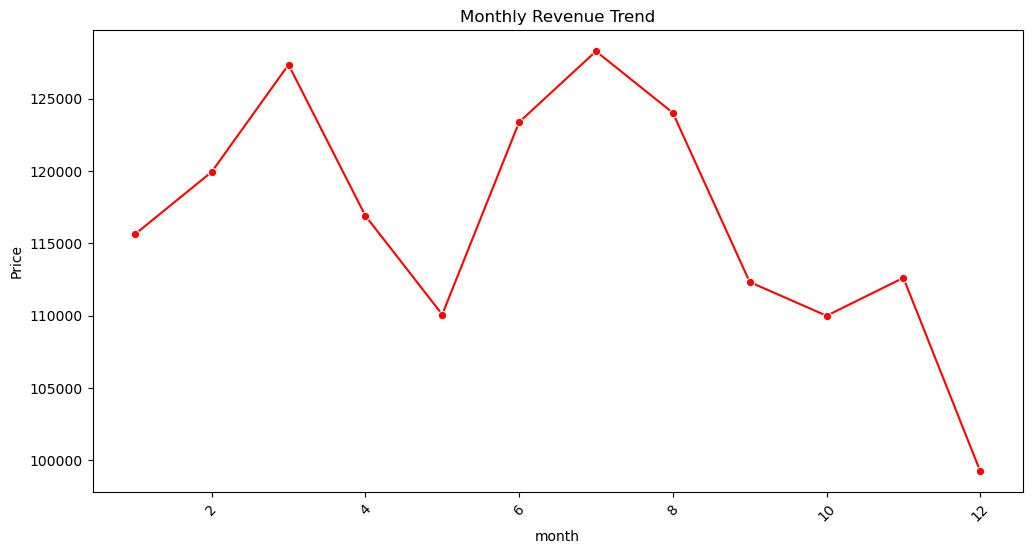

In [47]:
monthly_sales=df.groupby('month')['Price'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales,x='month',y='Price',marker='o',color='red')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.show()

In [62]:
monthly_sales['Change']=monthly_sales['Price'].pct_change()*100
monthly_sales

,month,Price,Change
0,1,115622.59,NaN
1,2,119944.85,3.738249
2,3,127363.52,6.185068
3,4,116914.12,-8.204390
4,5,110081.18,-5.844410
5,6,123386.77,12.087071
6,7,128291.99,3.975483
7,8,124037.60,-3.316177
8,9,112330.79,-9.438114
9,10,109995.15,-2.079252


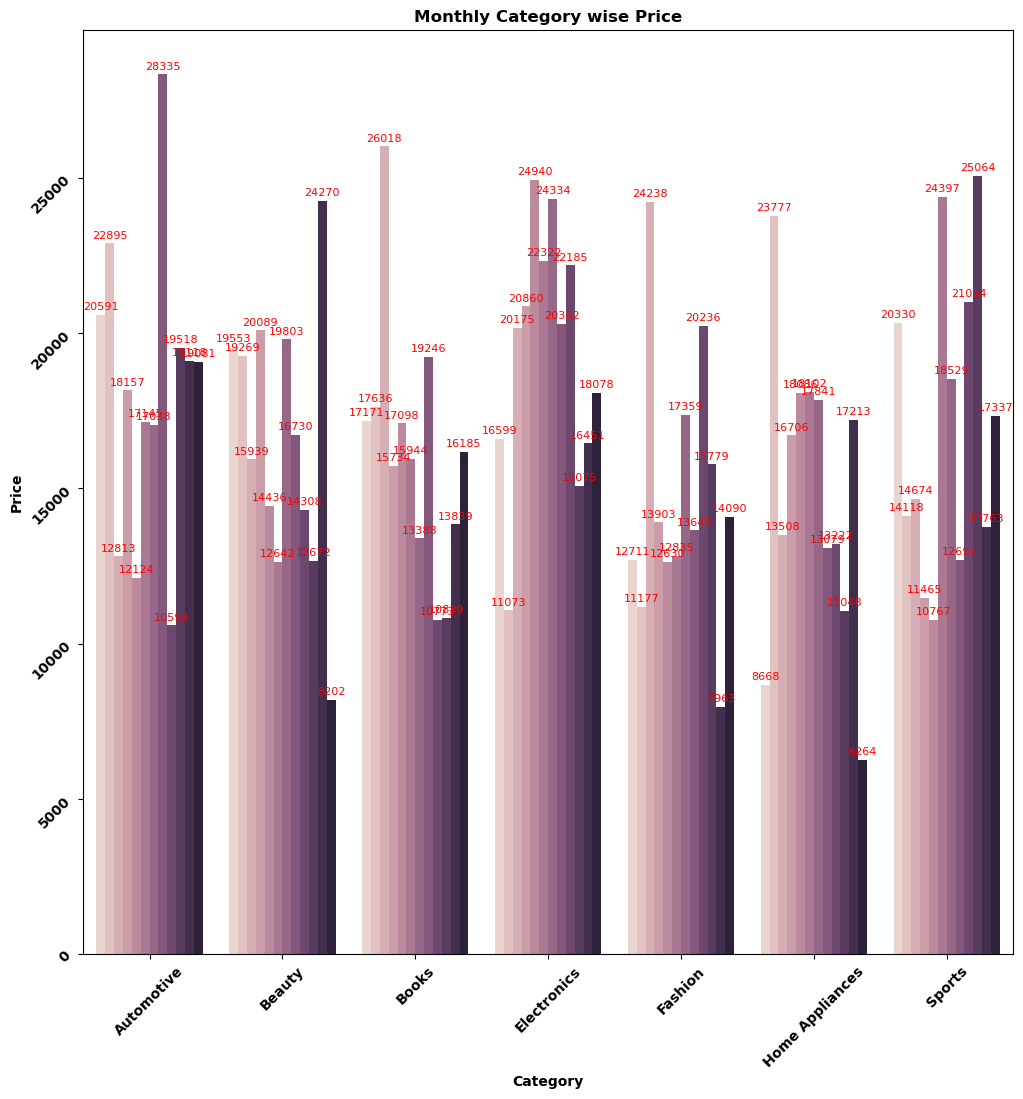

In [46]:
cat=df.groupby(['month','Category'])['Price'].sum().reset_index().round()
plt.figure(figsize=(12,12))
ax=sns.barplot(data=cat,x='Category',y='Price',hue='month',legend=False)
plt.xticks(rotation=45,color='black',fontweight='bold')
plt.yticks(rotation=45,color='black',fontweight='bold')
plt.xlabel('Category',color='black',fontweight='bold')
plt.ylabel('Price',color='black',fontweight='bold')
plt.title('Monthly Category wise Price',color='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container ,padding=2,fontsize=8,color='red')
plt.show()

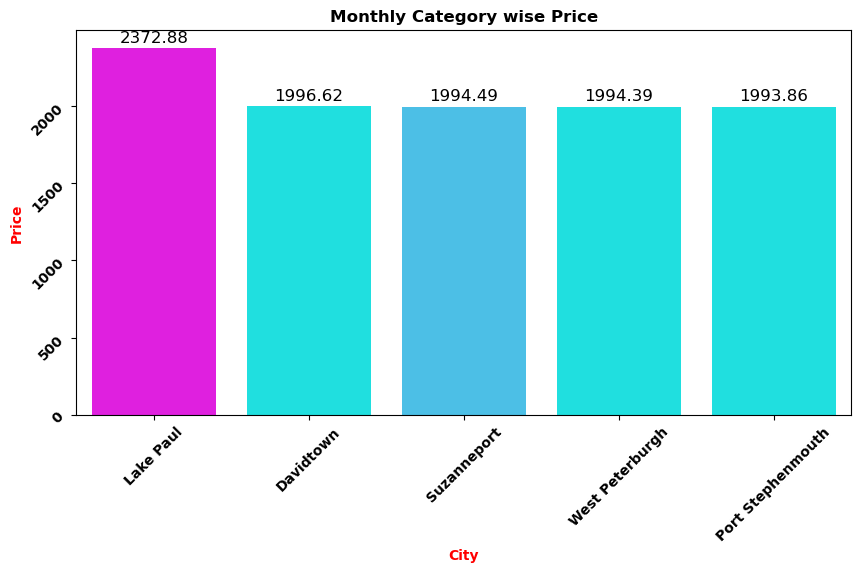

In [60]:
city=df.groupby(['month','Customer_City'])['Price'].sum().sort_values(ascending=False).reset_index().head(5)
plt.figure(figsize=(10,5))
ax=sns.barplot(data=city, x='Customer_City', y='Price', hue='month',legend=False,palette='cool')
plt.xticks(rotation=45,color='black',fontweight='bold')
plt.yticks(rotation=45,color='black',fontweight='bold')
plt.xlabel('City',color='red',fontweight='bold')
plt.ylabel('Price',color='red',fontweight='bold')
plt.title('Monthly Category wise Price',color='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container ,padding=2,fontsize=12,color='black')
plt.show()


   # 🇺🇸 Which products generate the most revenue ?





In [12]:
df['Revenue']=df['Price']*df['Quantity']
most=df.sort_values(by='Revenue',ascending=False).head(1)
most[['Product_Name','Revenue']].rename(columns={'Revenue':'Most Revenue generate'})

,Product_Name,Most Revenue generate
527,Budget Microwave,9972.45



  # 🇺🇸 Which city generates the highest revenue?
 

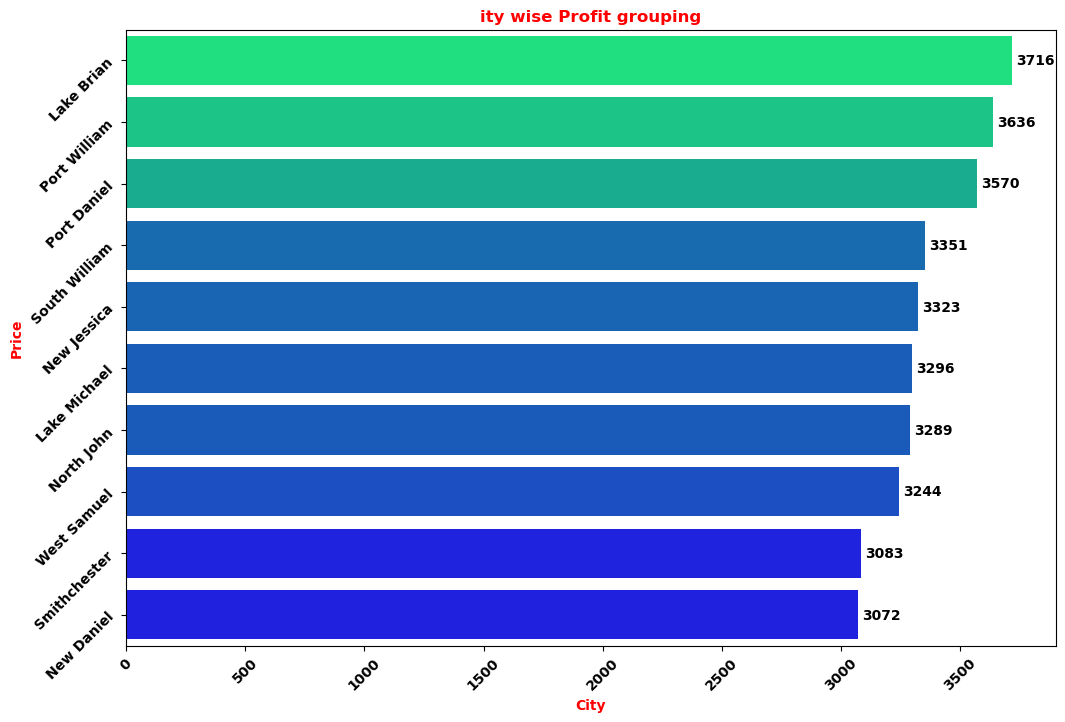

In [114]:
city=df.groupby('Customer_City')['Price'].sum().sort_values(ascending=False).reset_index().head(10).round()

plt.figure(figsize=(12,8))
ax=sns.barplot(data=city,x='Price',y='Customer_City',palette='winter',hue='Price',legend=False)
plt.title('ity wise Profit grouping',color='red',fontweight='bold')
plt.xlabel('City',color='red',fontweight='bold')
plt.ylabel('Price',color='red',fontweight='bold')
plt.xticks(rotation=45,color='black',fontweight='bold')
plt.yticks(rotation=45,color='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,padding=3,fontweight='bold')
plt.show()


 #  🇺🇸 Which city should we target for expansion?





In [26]:
city=df.groupby('Customer_City')['Price'].sum().sort_values(ascending=False).reset_index()
city

,Customer_City,Price
0,Lake Brian,3716.29
1,Port William,3635.67
2,Port Daniel,3569.98
3,South William,3350.97
4,New Jessica,3322.98
...,...,...
1329,Sheilahaven,15.14
1330,Santiagoville,14.25
1331,Kingland,11.33
1332,Lake Kenneth,6.97


In [30]:
order=df.groupby('Customer_City')['Order_ID'].count().reset_index()
order

,Customer_City,Order_ID
0,Aaronburgh,2
1,Aaronfort,1
2,Abbottton,1
3,Adamsfort,1
4,Adamtown,1
...,...,...
1329,Youngton,1
1330,Youngview,1
1331,Zacharyborough,1
1332,Zacharyview,1


In [38]:
avg_re=df.groupby('Customer_City')['Price'].sum()/df.groupby('Customer_City')['Order_ID'].count()
avg_re=avg_re.sort_values(ascending=False).reset_index()
avg_re

,Customer_City,0
0,Davidtown,1996.62
1,Suzanneport,1994.49
2,West Peterburgh,1994.39
3,Port Stephenmouth,1993.86
4,South Gregory,1991.77
...,...,...
1329,Sheilahaven,15.14
1330,Santiagoville,14.25
1331,Kingland,11.33
1332,Lake Kenneth,6.97


In [110]:
growth = df.groupby(['Customer_City','month'])['Price'].sum().groupby(level=1).pct_change()*100
growth = growth.sort_values(ascending=False).reset_index().head(5)
growth

,Customer_City,month,Price
0,Lake Kevinchester,10,26249.641320
1,Cheryltown,7,25101.584786
2,Lake Brian,12,12665.931156
3,Rodriguezbury,2,7519.815113
4,New Christinaland,1,7110.418251



  # 🇺🇸 Which category is driving our business?





In [81]:
category_sales=df.groupby('Category')['Price'].sum()
category_sales=category_sales.sort_values(ascending=False).reset_index()
category_sales

,Category,Price
0,Electronics,232394.56
1,Automotive,217407.58
2,Sports,204153.18
3,Beauty,197913.80
4,Books,193871.03
5,Home Appliances,177515.57
6,Fashion,176568.28


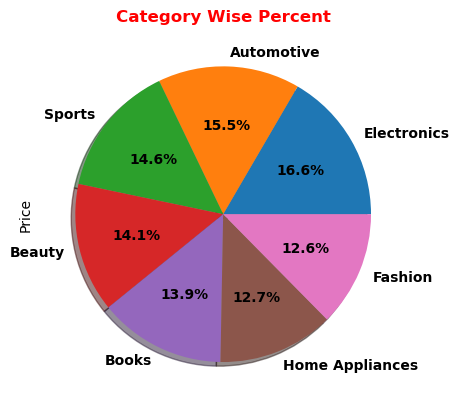

In [108]:
cat=df.groupby('Category')['Price'].sum()
catgory_percent=(cat/cat.sum())*100
percent=catgory_percent.sort_values(ascending=False).round(2)
percent

percent.plot(kind='pie',autopct='%1.1f%%',textprops={'weight':'bold','color':'black'},shadow=True)
plt.title('Category Wise Percent',color='red',fontweight='bold')
plt.show()

In [ ]:
6. 🇧🇩 কোন category underperform করছে এবং কেন?
   🇺🇸 Which category is underperforming and why?

   # low sales detection




  # 🇺🇸 Why are some orders getting cancelled?



In [9]:
df['Order_Status'].value_counts().reset_index()

,Order_Status,count
0,Delivered,375
1,Returned,353
2,Cancelled,341
3,Pending,331


In [101]:
cancelled=df[df['Order_Status']=='Cancelled']
cancelled.groupby('Customer_City')['Order_Status'].count().sort_values(ascending=False).head(5).reset_index()

,Customer_City,Order_Status
0,Mooremouth,2
1,Lake Jason,2
2,Port William,2
3,West Samuel,2
4,Port Jaclyn,1


In [104]:
cancelled.groupby('Delivery_Date')['Order_ID'].count().reset_index()

,Delivery_Date,Order_ID
0,2024-03-01,1
1,2024-03-02,1
2,2024-03-04,1
3,2024-03-07,2
4,2024-03-08,1
...,...,...
226,2025-02-25,1
227,2025-02-26,1
228,2025-02-27,1
229,2025-03-01,2


<Axes: xlabel='Payment_Method'>

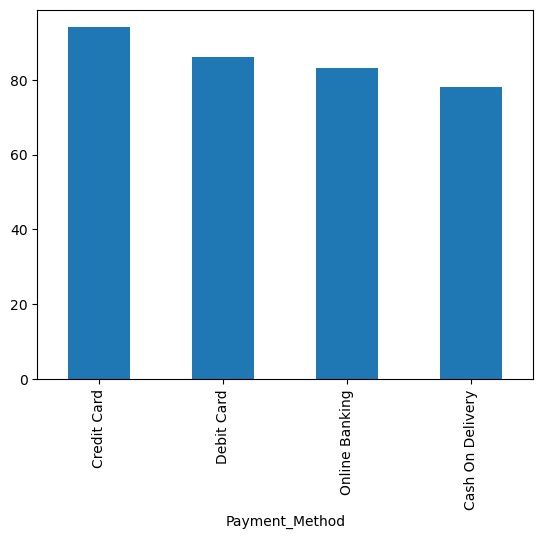

In [87]:
cancelled['Payment_Method'].value_counts().plot(kind='bar')


In [85]:
cancelled['Product_Name'].value_counts().sort_values(ascending=False).reset_index().head(25)

,Product_Name,count
0,Modern Jeans,10
1,Premium Refrigerator,8
2,Mega Sneakers,7
3,Smart Microwave,7
4,Premium Backpack,7
5,Modern Backpack,7
6,Eco Sunglasses,6
7,Hyper Microwave,6
8,Ultra Sneakers,6
9,Pro Camera,6



# What is the average delivery time and where are delays happening?

  



In [30]:
ave_day=df['Day'].mean().round(1)
print('average delay time :',ave_day)

average delay time : 15.3


In [15]:
city_delay=df.groupby('Customer_City')['Day'].mean().sort_values(ascending=False).reset_index()
city_delay

,Customer_City,Day
0,Vanessachester,31.0
1,Christinashire,31.0
2,Reyeschester,31.0
3,Mooreview,31.0
4,Cummingsbury,31.0
...,...,...
1329,Port Vickie,1.0
1330,Watsonchester,1.0
1331,Lake Aprilfort,1.0
1332,East Hailey,1.0


In [20]:
Status_delay=df.groupby('Order_Status')['Day'].mean().sort_values(ascending=False).round(1).reset_index()
Status_delay

,Order_Status,Day
0,Returned,15.7
1,Pending,15.5
2,Delivered,15.2
3,Cancelled,14.8


In [23]:
df['is_delay']=df['Day']>5
df[['Order_ID','Day','is_delay']]

,Order_ID,Day,is_delay
0,O00001,28,True
1,O00002,24,True
2,O00003,20,True
3,O00004,16,True
4,O00005,30,True
...,...,...,...
1395,O01396,14,True
1396,O01397,4,False
1397,O01398,25,True
1398,O01399,6,True


In [25]:
df['is_delay'].value_counts().reset_index()

,is_delay,count
0,True,1161
1,False,239


In [27]:
df.groupby(['Customer_City','Order_Status'])['Day'].mean().sort_values(ascending=False).reset_index()

,Customer_City,Order_Status,Day
0,Port Craig,Delivered,31.0
1,Cummingsbury,Cancelled,31.0
2,West Kathy,Cancelled,31.0
3,South Davidside,Cancelled,31.0
4,South Kimberly,Delivered,31.0
...,...,...,...
1376,North Williambury,Delivered,1.0
1377,South Bobby,Delivered,1.0
1378,Harrisshire,Delivered,1.0
1379,Guzmanberg,Delivered,1.0


In [33]:
print("1:Average delivery time is 15.3 days"
"(2:Cities like Vanessachester / Christinashire have higher delivery times)"
"Status Wise delay delivery time →15.2"
"(Around 1100 orders are delayed (>5 days)")

1:Average delivery time is 15.3 days(2:Cities like Vanessachester / Christinashire have higher delivery times)Status Wise delay delivery time →15.2(Around 1100 orders are delayed (>5 days)



   #  Which seller is performing the best?





In [37]:
df.groupby('Seller_Name')['Order_ID'].count().sort_values(ascending=False).reset_index().head(1)

,Seller_Name,Order_ID
0,Williams Group,4


In [53]:
df.groupby('Seller_Name')['Price'].sum().sort_values(ascending=False).reset_index().head(5)

,Seller_Name,Price
0,Smith Inc,4455.11
1,Smith Group,3837.13
2,Brown and Sons,3670.69
3,Allen LLC,3556.49
4,Williams and Sons,3393.70


In [39]:
df.groupby('Seller_Name')['Order_Status'].count().sort_values(ascending=False).reset_index().head(1)

,Seller_Name,Order_Status
0,Williams Group,4


In [52]:
cancel_df = df[df['Order_Status'] == 'Cancelled']
cancel_df.groupby('Seller_Name')['Order_Status'].size().sort_values(ascending=False).reset_index().head(1)

,Seller_Name,Order_Status
0,Martinez PLC,2



# Which seller is underperforming and why?

   

In [25]:
(df.groupby('Seller_Name').agg({
    'Order_ID':'count',
    'Price':'sum',
    'Day':'mean'
}).sort_values(by='Day',ascending=False).
    reset_index().rename(columns={'Order_ID':'Total_Order','Price':'Total_Price','Day':'Average_Day'}).head(5))

,Seller_Name,Total_Order,Total_Price,Average_Day
0,"Lee, Morrow and Finley",1,1064.21,31.0
1,Donaldson-Mitchell,1,339.80,31.0
2,Brown-Shields,1,510.45,31.0
3,Pierce-Peterson,1,371.29,31.0
4,Ritter Group,1,371.99,31.0


# Which customers generate the most revenue?





In [27]:
df.groupby('Customer_Name')['Price'].sum().sort_values(ascending=False).reset_index().head(1)


,Customer_Name,Price
0,Deborah Garcia,3985.37


# Who are repeat customers and how valuable are they?




In [39]:
df.groupby('Customer_Name').agg({
    'Order_ID':'count',
    'Price':'sum'
}).sort_values(by ='Order_ID',ascending=False).rename(columns={'Order_ID':'repeat_count'}).reset_index().head(5)


,Customer_Name,repeat_count,Price
0,David Smith,3,3760.92
1,Debra Moore,2,748.36
2,Melissa Jackson,2,1306.37
3,Stacy Hayes,2,3502.08
4,David Robinson,2,748.98


# Which payment method is most popular 





In [46]:
df.groupby('Payment_Method').agg({
    'Order_ID':'count',
    'Price':'sum'
}).sort_values(by='Order_ID',ascending=False).rename(columns={'Order_ID':'id_count'}).reset_index()

,Payment_Method,id_count,Price
0,Debit Card,355,342944.87
1,Credit Card,354,347697.48
2,Cash On Delivery,349,349826.78
3,Online Banking,342,359354.87


 # Which products are underperforming





In [51]:
df.groupby('Product_Name')['Price'].sum().sort_values().reset_index().head(1)

,Product_Name,Price
0,Ultra Vacuum Cleaner,6373.97


In [58]:
cancell=df[df['Order_Status']=='Cancelled']
cancell[cancell['Product_Name']=='Ultra Vacuum Cleaner']


,Order_ID,Customer_Name,Customer_City,Product_Name,Category,Price,Quantity,Order_Date,Delivery_Date,Payment_Method,Order_Status,Seller_Name,year,month,Day
304,O00305,Lisa Schultz,East Peter,Ultra Vacuum Cleaner,Books,698.70,2,2025-07-01,2025-01-15,Debit Card,Cancelled,Alexander-Roth,2025,7,15
907,O00908,Samantha Alvarez,Hernandezhaven,Ultra Vacuum Cleaner,Beauty,386.97,1,2024-05-13,2024-05-20,Online Banking,Cancelled,Hood PLC,2024,5,20


#  Does price impact sales?

    



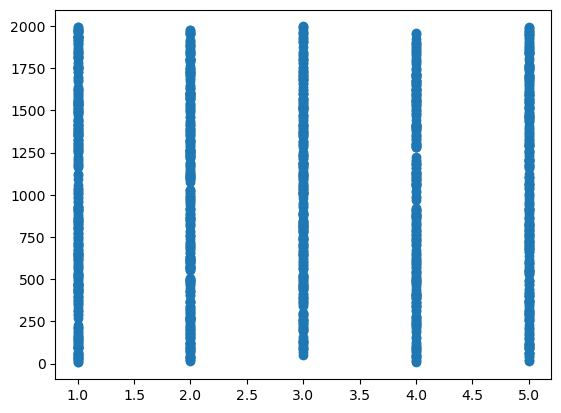

In [64]:
plt.scatter(df['Quantity'],df['Price'])

<Axes: xlabel='Quantity', ylabel='Price'>

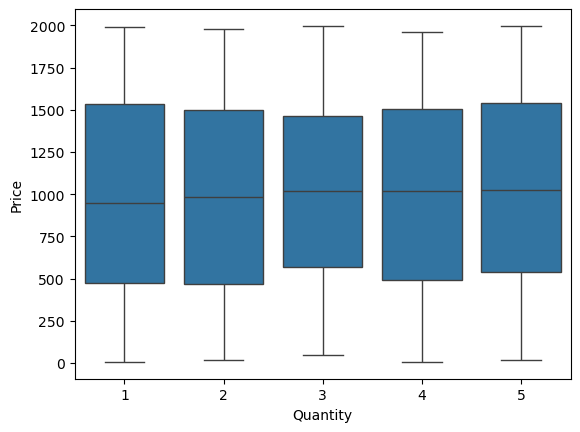

In [65]:
sns.boxplot(x='Quantity', y='Price', data=df)

#  At what time (date/month) do sales peak?




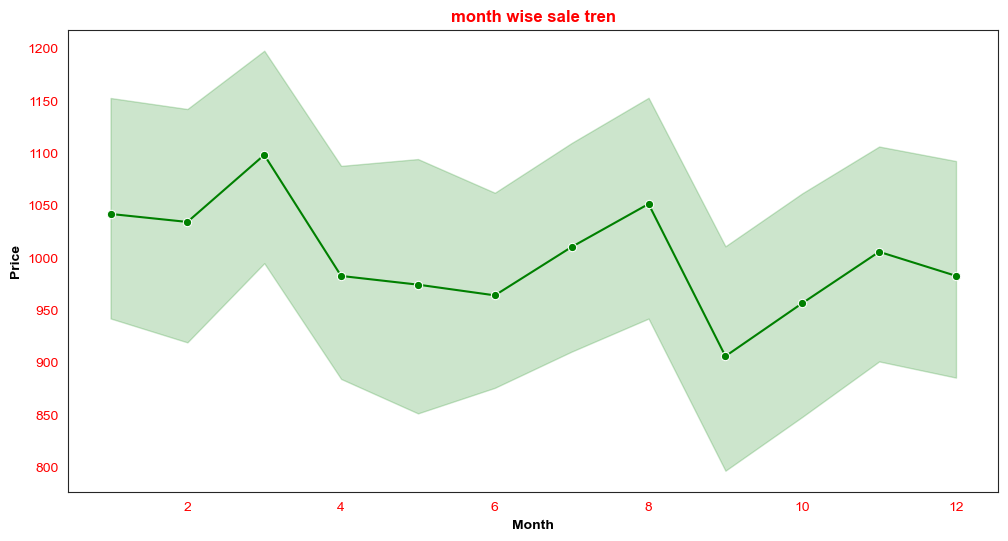

In [99]:
df.groupby('month')['Price'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(data=df,x='month',y='Price',marker='o',color='green')
plt.title('month wise sale tren',color='red',fontweight='bold')
plt.xlabel('Month',color='black',fontweight='bold')
plt.ylabel('Price',color='black',fontweight='bold')
plt.xticks(color='red')
plt.yticks(color='red')
plt.show()

# What is the order completion rate?





In [122]:
total=len(df)
complet=df[df['Order_Status'] == 'Delivered'].shape[0]
complet_percen=(complet / total) * 100
print('completed Percentage:',complet_percen)

completed Percentage: 26.785714285714285
